In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

Function 2: Optimising Noisy Models

This corresponds to trying to optimise an unknown machine learning model. However, the initialization of the model is very important, meaning your observations will be very noisy, and the problem might have a lot of local optima! You are trying to make the model’s log-likelihood as large as possible.

**Problem: Optimising Noisy Models**

**What does this mean?**

**Unknown Model:**
We are trying to optimize (find the best input for) a function that we cannot see or write down explicitly. This is common in machine learning when you want to tune hyperparameters or inputs to maximize some performance metric.

**Noisy Observations:**
Every time you try an input, the output (observation) you get is noisy—it has random error. This could be due to randomness in the model, data, or measurement process.

**Many Local Optima:**
The function you are optimizing is not smooth and simple; it has many peaks and valleys (local optima). This means it’s easy to get stuck in a “good” but not “best” solution.

**Log-Likelihood Maximization:**
In machine learning, the log-likelihood is a measure of how well your model explains the data. Maximizing it means you want to find the input (or hyperparameters) that make your model fit the data as well as possible.

**Real-World Analogy**
Imagine you are tuning the settings of a complicated machine (like a car engine) to get the best performance.

Every time you change the settings and measure the output, the result is a bit random (noisy).
Sometimes, a setting gives you a good result, but there might be an even better setting elsewhere.
Your goal is to find the settings that give you the best average performance, not just a lucky high reading.

In [2]:
def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = eval(formatted_query)  # Ensure eval is safe or replace with a safer alternative
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [3]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.66579958, 0.12396913],
        [0.87779099, 0.7786275 ],
        [0.14269907, 0.34900513],
        [0.84527543, 0.71112027],
        [0.45464714, 0.29045518],
        [0.57771284, 0.77197318],
        [0.43816606, 0.68501826],
        [0.34174959, 0.02869772],
        [0.33864816, 0.21386725],
        [0.70263656, 0.9265642 ]]),
 10)

In [4]:
#new_query_1 =  np.array([1.00000e-06, 9.99999e-01])
#new_query_2 =  np.array([0.999999, 0.999999])
#new_query_3 =  np.array([1.e-06, 1.e-06])
#new_query_4 =  np.array([9.99999e-01, 1.00000e-06])
#new_query_5 =  np.array([6.76767e-01, 1.00000e-06])
#X = np.vstack([X, new_query_1, new_query_2, new_query_3, new_query_4, new_query_5])
#X

queries = queries_for_function(2)
X = np.vstack([X, queries])
X, len(X)

(array([[6.65799580e-01, 1.23969128e-01],
        [8.77790989e-01, 7.78627501e-01],
        [1.42699074e-01, 3.49005131e-01],
        [8.45275429e-01, 7.11120267e-01],
        [4.54647141e-01, 2.90455180e-01],
        [5.77712844e-01, 7.71973184e-01],
        [4.38166062e-01, 6.85018257e-01],
        [3.41749593e-01, 2.86977198e-02],
        [3.38648157e-01, 2.13867246e-01],
        [7.02636557e-01, 9.26564198e-01],
        [5.65656000e-01, 9.99999000e-01],
        [6.66666000e-01, 2.82829000e-01],
        [8.18181000e-01, 1.91920000e-01],
        [5.55555000e-01, 1.00000000e-06],
        [5.75757000e-01, 4.64647000e-01],
        [1.72728000e-01, 6.25087000e-01],
        [3.53170000e-02, 1.43501000e-01],
        [8.66822000e-01, 4.67368000e-01],
        [1.19428000e-01, 9.50321000e-01],
        [2.63265000e-01, 6.51415000e-01],
        [9.99999000e-01, 5.25252000e-01],
        [9.99999000e-01, 5.25252000e-01],
        [8.48484000e-01, 9.79797000e-01],
        [8.48990000e-01, 4.0000000

In [5]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([ 0.53899612,  0.42058624, -0.06562362,  0.29399291,  0.21496451,
         0.02310555,  0.24461934,  0.03874902, -0.01385762,  0.61120522]),
 10)

In [6]:
#y = np.append(y, [0.0, 1.517648729565899e-192, 2.31546114628124e-248, 0.0, 5.4713831123687026e-170], axis=0)
#y

observations = observations_for_function(2)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([ 0.53899612,  0.42058624, -0.06562362,  0.29399291,  0.21496451,
         0.02310555,  0.24461934,  0.03874902, -0.01385762,  0.61120522,
         0.00383348,  0.45575856,  0.16684519, -0.01344612,  0.1062046 ,
         0.0482295 , -0.02461208,  0.74906492, -0.00791856, -0.06233066,
        -0.02172702,  0.01192909,  0.06253043,  0.36763342,  0.34985542]),
 25)

In [7]:
best_idx = np.argmax(y)
print("Best input so far:", X[best_idx])
print("Best log-likelihood so far:", y[best_idx])

Best input so far: [0.866822 0.467368]
Best log-likelihood so far: 0.7490649223844393


In [8]:
def best_observation(y):
    best_idx = np.argmax(y)  # Find the index where y is closest to zero
    best_observation_so_far = y[best_idx]
    best_query_so_far = X[best_idx]
    print("Best observation so far (closest to zero):", best_observation_so_far)
    print("Best query so far:", best_query_so_far)
    return best_observation_so_far, best_query_so_far

best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.7490649223844393
Best query so far: [0.866822 0.467368]


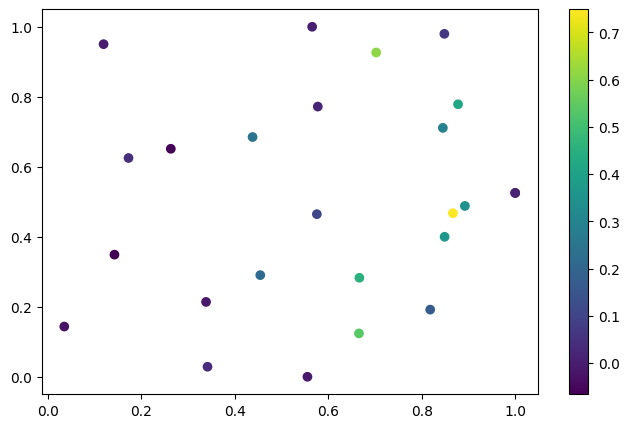

In [9]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

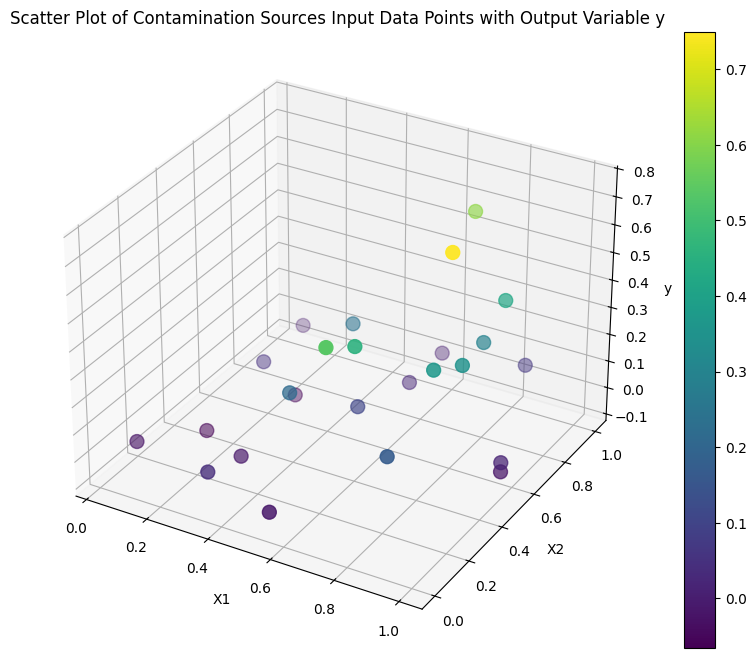

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


**Acquisiton Functions**

In [11]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

**Input Sampling Methods**

In [12]:
def exploration_grid():
    x1_grid = np.linspace(0.000001, 0.999999, 100)
    x2_grid = np.linspace(0.000001, 0.999999, 100)

    x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()]).T

    return x_grid

def exploitation_grid(center, delta=0.05):
    """
    Create a grid for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    x1, x2 = center
    x1_grid = np.linspace(max(0.000001, x1 - delta), min(0.999999, x1 + delta), 100)
    x2_grid = np.linspace(max(0.000001, x2 - delta), min(0.999999, x2 + delta), 100)

    x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()]).T

    return x_grid

def exploration_latin_hypercube():
    """
    Create a Latin Hypercube sample for exploration.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (0.000001, 0.999999),  # x1
        (0.000001, 0.999999)   # x2

    ]
    sampler = qmc.LatinHypercube(d=2)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

def exploitation_latin_hypercube(center, delta=0.05):
    """
    Create a Latin Hypercube sample for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (max(0.000001, center[0] - delta), min(0.999999, center[0] + delta)),  # x1
        (max(0.000001, center[1] - delta), min(0.999999, center[1] + delta))   # x2
    ]
    sampler = qmc.LatinHypercube(d=2)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

In [13]:
def query_black_box_function_with_default_kernel(X, y, x_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)
    
    
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    x = x.reshape(1,2)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}) is {y_pred[0]}") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel used: ", model.kernel_, "Score: ", model.score(X, y))
    
    return x, y_pred

In [14]:
def next_query_with_default_kernel(X, y, x_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

Exploration: Explore the whole space with defalut RBF Kernel

In [15]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploration_grid())

Random Query: 0.710652-0.921982


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.999999) is 14.890749885222881
Index of maximum acquisition function value:  9900
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9433597278133864


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is 1.5096830395851968
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9433597278133864


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.707070-0.000001)
Predicted Value at (0.707070-0.000001) is 1.5700926844480847
Index of maximum acquisition function value:  70
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9433597278133864


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.999999) is 14.8907

Exploitation: Exploit around the point below

In [16]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.7490649223844393
Best query so far: [0.866822 0.467368]


In [17]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploitation_grid(best_query_so_far))

Random Query: 0.023701-0.787437


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.874398-0.517368)
Predicted Value at (0.874398-0.517368) is 0.6737758226822468
Index of maximum acquisition function value:  9957
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9433597278133864


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.816822-0.417368)
Predicted Value at (0.816822-0.417368) is 0.6060937998421982
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9433597278133864


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.816822-0.417368)
Predicted Value at (0.816822-0.417368) is 0.6060937998421982
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9433597278133864


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.816822-0.417368)
Predicted Value at (0.816822-0.417368) is 0.606093

Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters with gp_minimize

In [18]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct

def query_black_box_function_with_kernel_choice(X, y, x_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-3, 1e3))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-3, 1e3))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-3, 1e3))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)


    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    x = x.reshape(1, 2)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}) is {y_pred[0]}")
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel used: ", kernel_type, "Score: ", model.score(X, y))

    return x, y_pred

In [19]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    next_query, y_pred = query_black_box_function_with_kernel_choice(
        X, y, exploration_grid(), 
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred[0]

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=50,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_kernel_choice(
    X, y, exploration_grid(),
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.747474-0.535353)
Predicted Value at (0.747474-0.535353) is 0.29713309358100953
Index of maximum acquisition function value:  5374
Kernel used:  RBF Score:  0.8598246164469301


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999)
Predicted Value at (0.999999-0.999999) is 0.1725256464690982
Index of maximum acquisition function value:  9999
Kernel used:  RationalQuadratic Score:  -0.0010515485283866255


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.858585-0.454546)
Predicted Value at (0.858585-0.454546) is 0.7965770356743456
Index of maximum acquisition function value:  4585
Kernel used:  RBF Score:  0.9995649695322955


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.939393-0.191920)
Predicted Value at (0.939393-0.191920) is 0.2370948073609173
Index of maximum acquisition function value:  1993


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.2613181184961887
Index of maximum acquisition function value:  99
Kernel used:  Matern Score:  0.19255066569945134


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.17713672033737082
Index of maximum acquisition function value:  99
Kernel used:  RationalQuadratic Score:  0.2033086970441912


...



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.797979-0.484849)
Predicted Value at (0.797979-0.484849) is 0.9490675304420298
Index of maximum acquisition function value:  4879
Kernel used:  Matern Score:  0.9995668609863159


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.797979-0.484849)
Predicted Value at (0.797979-0.484849) is 0.9598065619008881
Index of maximum acquisition function value:  4879
Kernel used:  Matern Score:  0.9995668609863173


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.797979-0.484849)
Predicted Value at (0.797979-0.484849) is 0.9347829239350031
Index of maximum acquisition function value:  4879
Kernel used:  Matern Score:  0.9995668609863181


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.868686-0.474748)
Predicted Value at (0.868686-0.474748) is 0.48839678611249365
Index of maximum acquisition function value:  4786
Kernel used:  Matern Score:  0.9995668609863189
Best Parameters: rbf_lengthscale=0.40874864401463873, noise_assumption=1e-10, restarts=0, beta=2.0636366599945504, acquisition_func=expected_improvement, kernel_type=Matern


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.797979-0.484849)
Predicted Value at (0.797979-0.484849) is 0.9799727199877836
Index of maximum acquisition function value:  4879
Kernel used:  Matern Score:  0.9995668609863171


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


(array([[0.7979792 , 0.48484852]]), array([0.97997272]))

Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with gp_minimize

In [20]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploration_grid(), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.797979-0.484849)
Predicted Value at (0.797979-0.484849) is 0.9799727199877836
Index of maximum acquisition function value:  4879
Kernel used:  Matern Score:  0.9995668609863171


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


(array([[0.7979792 , 0.48484852]]), array([0.97997272]))

Exploitation: Expoit for Radiation Source 1 around the point below

In [21]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.7490649223844393
Best query so far: [0.866822 0.467368]


In [22]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploitation_grid(best_query_so_far), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.816822-0.477974)
Predicted Value at (0.816822-0.477974) is 0.9857734972524743
Index of maximum acquisition function value:  6000
Kernel used:  Matern Score:  0.9995668609863171


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


(array([[0.816822  , 0.47797406]]), array([0.9857735]))

Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters using from bayes_opt import BayesianOptimization

In [23]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_kernel_choice(
        X, y, exploration_grid(),
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred[0]

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 3),  # 0: RBF, 1: Matern, 2: RationalQuadratic, 3: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_kernel_choice(
    X, y, exploration_grid(),
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.858585-0.464647)
Predicted Value at (0.858585-0.464647) is 0.5402318634020684
Index of maximum acquisition function value:  4685
Kernel used:  RationalQuadratic Score:  0.913984878978538
| 1         | -0.5402   | 1.498     | 2.901     | 2.196     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.858585-0.464647)
Predicted Value at (0.858585-0.464647) is 0.6110002820188223
Index of maximum acquisition function value:  4685
Kernel used:  RationalQuadratic Score:  0.998047048930352
| 2         | -0.611    | 0.2323    | 2.7

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.1833088648553856
Index of maximum acquisition function value:  99
Kernel used:  RationalQuadratic Score:  0.2358209164658881
| 6         | -0.1833   | 1.517     | 1.697     | 1.962     | 0.1396    | 0.08199   | 5.555     |


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


...



PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is 0.056332437319403086
Index of maximum acquisition function value:  0
Kernel used:  DotProduct Score:  0.03241223514770586
| 52        | -0.05633  | 2.294     | 1.0       | 2.67      | 0.01      | 1e-10     | 4.548     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.04146805795299861
Index of maximum acquisition function value:  0
Kernel used:  DotProduct Score:  0.23891108005314665
| 53        | 0.04147   | 1.58      | 1.513     | 3.0       | 0.01      | 1e-10     | 8.658     |


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.383839)
Predicted Value at (0.999999-0.383839) is 0.24471096972011772
Index of maximum acquisition function value:  3899
Kernel used:  RationalQuadratic Score:  0.2679387638594384
| 54        | -0.2447   | 0.1295    | 1.155     | 2.384     | 0.9677    | 0.06518   | 4.704     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -0.034890992773619865
Index of maximum acquisition function value:  0
Kernel used:  DotProduct Score:  0.24322390087378365
| 55        | 0.03489   | 1.233     | 1.0       | 3.0       | 0.01      | 1e-10     | 6.139     |
Best Parameters: rbf_lengthscale=0.01, noise_assumption=1e-10, restarts=8, beta=1.90560281059474, kernel_type=DotProduct, acquisition_func=probability_of_improvement_with_exploration_term


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.00

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


(array([[1.e-06, 1.e-06]]), array([-0.0355827]))

Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with BaysianOptimization

In [24]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploration_latin_hypercube(), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.691717-0.074025)
Predicted Value at (0.691717-0.074025) is 0.23890762286114747
Index of maximum acquisition function value:  0
Kernel used:  DotProduct Score:  0.2378072191729066


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


(array([[0.69171658, 0.074025  ]]), array([0.23890762]))

Exploitation: Expoit for Radiation Source 1 around the point below

In [25]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.7490649223844393
Best query so far: [0.866822 0.467368]


In [26]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploitation_latin_hypercube(best_query_so_far), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.912461-0.477944)
Predicted Value at (0.912461-0.477944) is 0.3112014586304372
Index of maximum acquisition function value:  0
Kernel used:  DotProduct Score:  0.2406503055719179


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


(array([[0.91246142, 0.47794421]]), array([0.31120146]))